# Чтение датасета обработка, нормализация, бейзлайн


In [1]:
import numpy as np
import pandas as pd
ful_input = '/kaggle/input/journey-to-springfield1'

In [5]:
#Посмотрим на размеры картинок

from PIL import Image
import os

dataset_path = '/kaggle/input/journey-to-springfield1/train/simpsons_dataset'

widths = []
heights = []

for i, class_folder in enumerate(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_folder)
    if i > len(os.listdir(dataset_path)):
        break
    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            if filename.endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, filename)
                try:
                    with Image.open(img_path) as img:
                        widths.append(img.width)
                        heights.append(img.height)
                except:
                    print(f'Не удалось прочитать файл {img_path}')

print(f'Макс. ширина: {max(widths)}')
print(f'Мин. ширина: {min(widths)}')
print(f'Средняя ширина: {sum(widths) / len(widths):.2f}')

print(f'Макс. высота: {max(heights)}')
print(f'Мин. высота: {min(heights)}')
print(f'Средняя высота: {sum(heights) / len(heights):.2f}')


Макс. ширина: 1912
Мин. ширина: 256
Средняя ширина: 409.30
Макс. высота: 1072
Мин. высота: 256
Средняя высота: 416.88


## будем обрезать картинки до 128*128 

## Расчитаем среднее и отклонение для нормализации:

In [33]:
#расчет среднего и отклонения

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm

transform_for_stats = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='/kaggle/input/journey-to-springfield1/train/simpsons_dataset', transform=transform_for_stats)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

mean = 0.
std = 0.
nb_samples = 0.

for i, (data, _) in tqdm(enumerate(loader)):
    batch_samples = data.size(0)
    data = data.view(batch_samples, data.size(1), -1)  # (batch, channels, pixels)
    mean += data.mean(2).sum(0)  # mean по всем пикселям в каждом канале
    std += data.std(2).sum(0)    # std по всем пикселям в каждом канале
    nb_samples += batch_samples
    if i > len(loader) // 10:
        break

mean /= nb_samples
std /= nb_samples

print('Mean:', mean)
print('Std:', std)

66it [00:03, 20.63it/s]

Mean: tensor([0.4673, 0.4138, 0.3582])
Std: tensor([0.2077, 0.1869, 0.2190])


### Создаем DataLoader'ы

In [37]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dir = ful_input + '/train/simpsons_dataset'
test_dir = ful_input + '/testset'

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True) 

## Архитектура бейзлайна

In [43]:
from torch import nn
import torch.nn as nn

import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),         # 128x128x3 -> 128x128x32
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),                                    # 64x64x32

    nn.Conv2d(32, 64, kernel_size=3, padding=1),        # 64x64x32 -> 64x64x64
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),                                    # 32x32x64

    nn.Conv2d(64, 128, kernel_size=3, padding=1),       # 32x32x64 -> 32x32x128
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),                                    # 16x16x128

    nn.Flatten(),
    nn.Dropout(0.3),                                    
    nn.Linear(128*16*16, 128),                          # 16*16*128 -> 128

    nn.ReLU(),
    nn.Dropout(0.3),                                    
    nn.Linear(128, 42)                                 
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'


## Начинаем Обучение бейзлайна

In [59]:
import matplotlib.pyplot as plt

def model_train(model, train_loader, test_loader, max_epoch, optimizer, criterion, metric):
    losses = []
    metric_values = {'train':[],'test':[]}
    #torch.cuda.empty_cache()
    for epoch in tqdm(range(max_epoch)):
        model.train()
        epoch_loss = 0
        train_metric_epoch = []
        for x_batch, y_batch in train_loader:
            x_batch,y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            _, preds = torch.max(output, axis=-1)
            metric_value = metric(y_batch, preds)
            train_metric_epoch.append(metric_value)
        metric_values['train'].append(np.mean(train_metric_epoch))
        losses.append(epoch_loss/len(train_loader))

        model.eval()
        with torch.no_grad():
            test_metric_epoch = []
            for x_batch, y_batch in test_loader:
                x_batch,y_batch = x_batch.to(device), y_batch.to(device)
                output = model(x_batch)
                _, preds = torch.max(output, axis=-1)
                metric_value = metric(y_batch, preds)
                test_metric_epoch.append(metric_value)
            metric_values['test'].append(np.mean(test_metric_epoch))
            print(metric_values)
    # График лосса
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train Loss over Epochs')
    plt.legend()
    plt.show()

    # График метрик
    plt.figure(figsize=(10, 5))
    plt.plot(metric_values['train'], label='Train Metric')
    plt.plot(metric_values['test'], label='Test Metric')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.title('Train & Test Metrics over Epochs')
    plt.legend()
    plt.show()

    return metric_values


  0%|          | 0/10 [00:00<?, ?it/s]

{'train': [0.17847821568459518], 'test': [0.34693165978732915]}


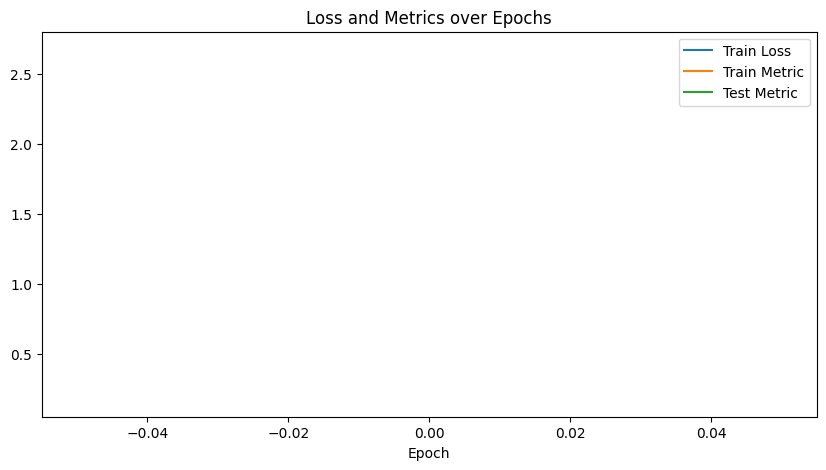

 10%|█         | 1/10 [00:33<05:04, 33.88s/it]

{'train': [0.17847821568459518, 0.2922314140249807], 'test': [0.34693165978732915, 0.41835471901313553]}


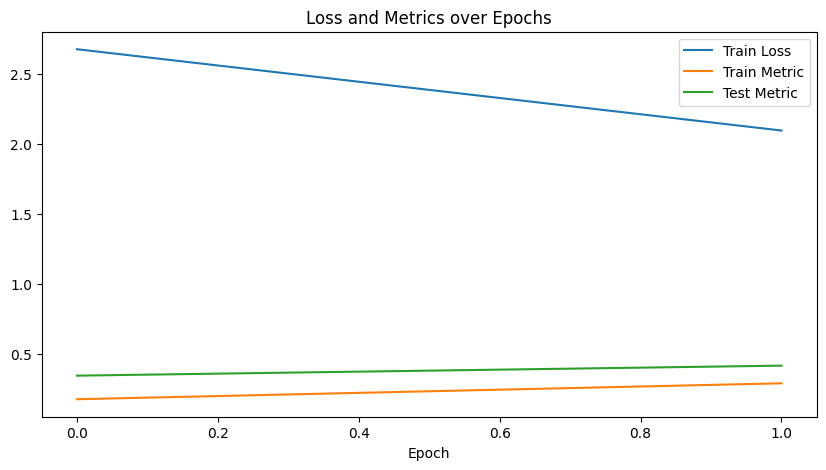

 20%|██        | 2/10 [01:07<04:30, 33.80s/it]

{'train': [0.17847821568459518, 0.2922314140249807, 0.33733091754346617], 'test': [0.34693165978732915, 0.41835471901313553, 0.4419805783195906]}


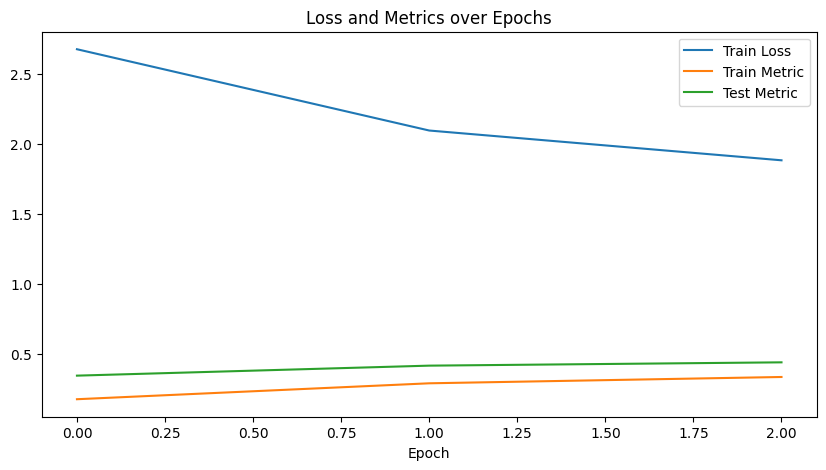

 30%|███       | 3/10 [01:41<03:56, 33.75s/it]

{'train': [0.17847821568459518, 0.2922314140249807, 0.33733091754346617, 0.3668905718886263], 'test': [0.34693165978732915, 0.41835471901313553, 0.4419805783195906, 0.4713090502199739]}


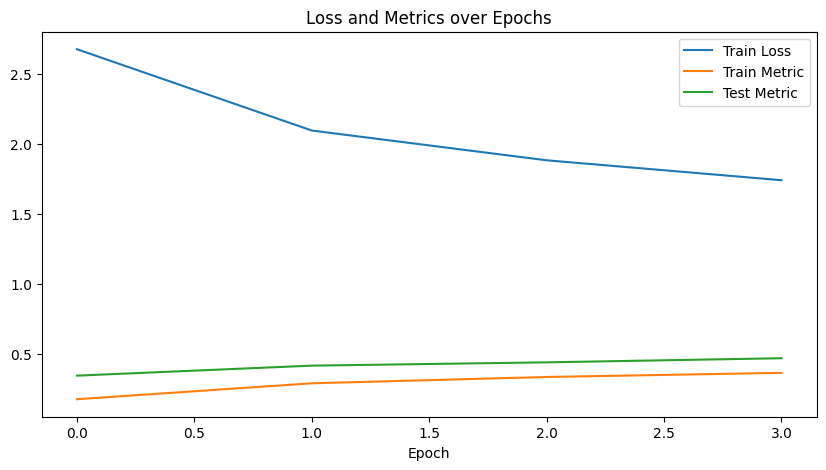

 40%|████      | 4/10 [02:14<03:21, 33.58s/it]

{'train': [0.17847821568459518, 0.2922314140249807, 0.33733091754346617, 0.3668905718886263, 0.3854623871529359], 'test': [0.34693165978732915, 0.41835471901313553, 0.4419805783195906, 0.4713090502199739, 0.49034540636984325]}


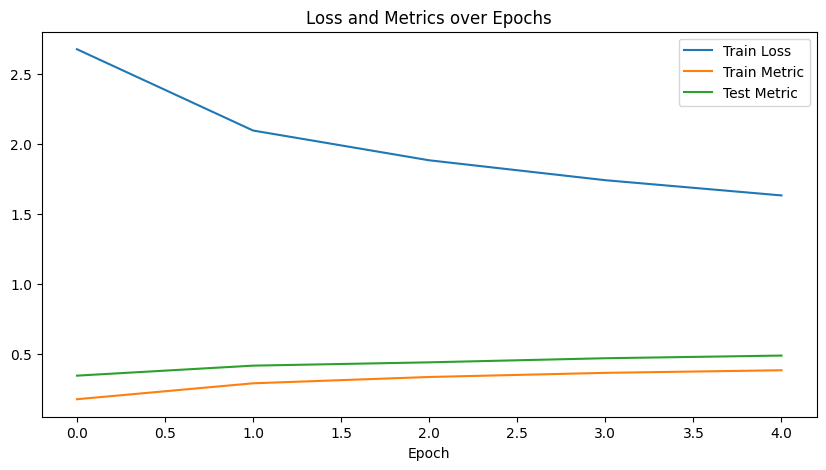

 50%|█████     | 5/10 [02:47<02:47, 33.44s/it]

{'train': [0.17847821568459518, 0.2922314140249807, 0.33733091754346617, 0.3668905718886263, 0.3854623871529359, 0.40209319814439176], 'test': [0.34693165978732915, 0.41835471901313553, 0.4419805783195906, 0.4713090502199739, 0.49034540636984325, 0.5073480418894933]}


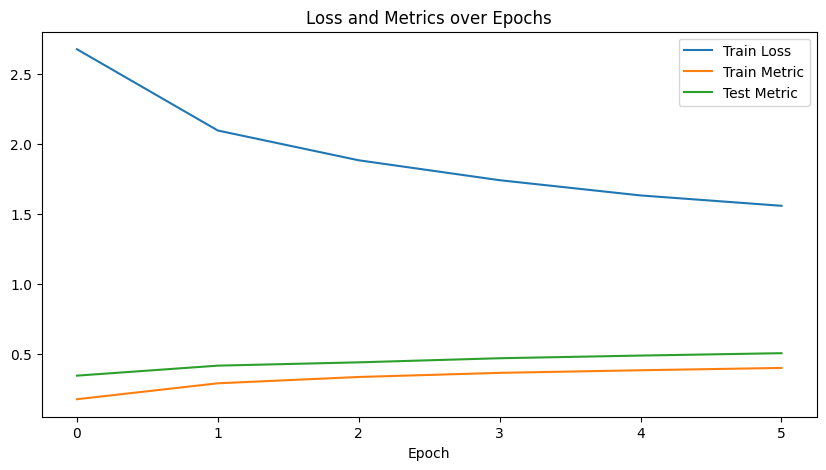

 60%|██████    | 6/10 [03:20<02:13, 33.34s/it]

{'train': [0.17847821568459518, 0.2922314140249807, 0.33733091754346617, 0.3668905718886263, 0.3854623871529359, 0.40209319814439176, 0.4225727111364888], 'test': [0.34693165978732915, 0.41835471901313553, 0.4419805783195906, 0.4713090502199739, 0.49034540636984325, 0.5073480418894933, 0.5165604087312518]}


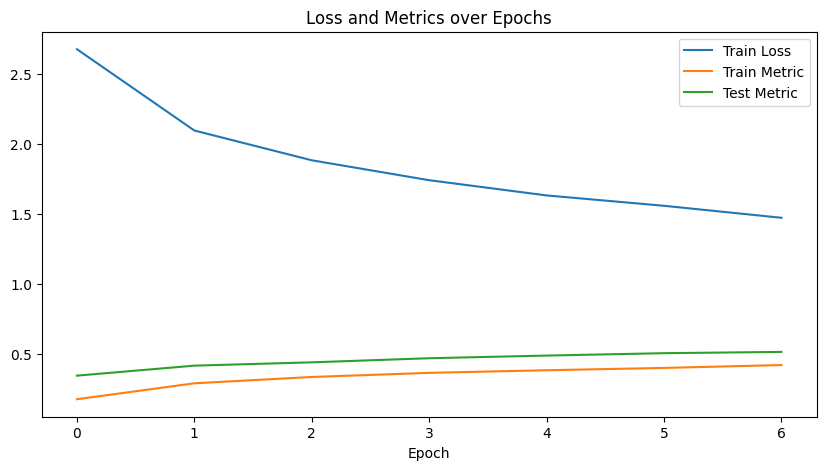

 70%|███████   | 7/10 [03:54<01:40, 33.36s/it]

{'train': [0.17847821568459518, 0.2922314140249807, 0.33733091754346617, 0.3668905718886263, 0.3854623871529359, 0.40209319814439176, 0.4225727111364888, 0.4329910613473629], 'test': [0.34693165978732915, 0.41835471901313553, 0.4419805783195906, 0.4713090502199739, 0.49034540636984325, 0.5073480418894933, 0.5165604087312518, 0.5236176257382813]}


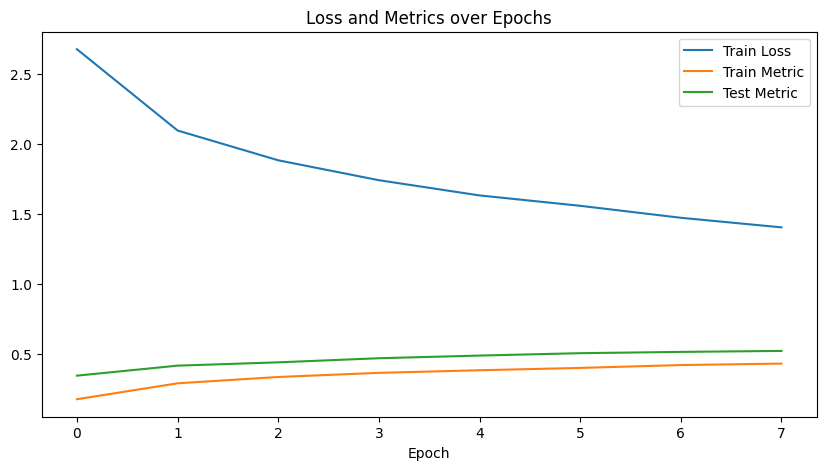

 80%|████████  | 8/10 [04:27<01:06, 33.35s/it]

{'train': [0.17847821568459518, 0.2922314140249807, 0.33733091754346617, 0.3668905718886263, 0.3854623871529359, 0.40209319814439176, 0.4225727111364888, 0.4329910613473629, 0.44709498911342543], 'test': [0.34693165978732915, 0.41835471901313553, 0.4419805783195906, 0.4713090502199739, 0.49034540636984325, 0.5073480418894933, 0.5165604087312518, 0.5236176257382813, 0.5415746868249313]}


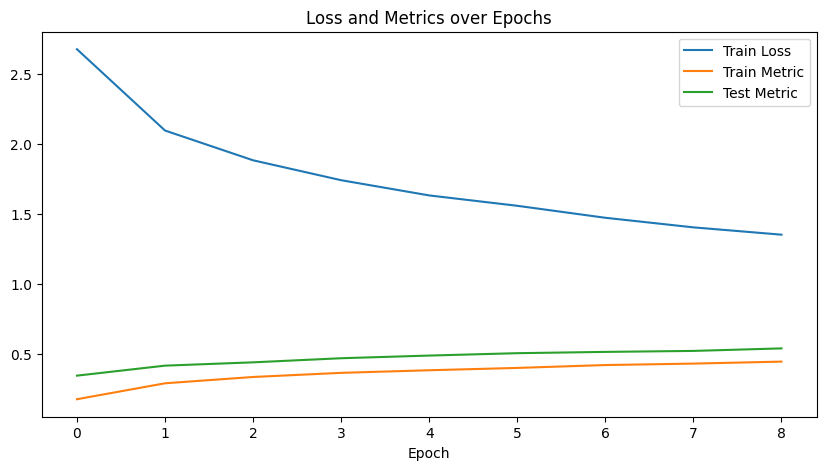

 90%|█████████ | 9/10 [05:01<00:33, 33.36s/it]

{'train': [0.17847821568459518, 0.2922314140249807, 0.33733091754346617, 0.3668905718886263, 0.3854623871529359, 0.40209319814439176, 0.4225727111364888, 0.4329910613473629, 0.44709498911342543, 0.45911663173847495], 'test': [0.34693165978732915, 0.41835471901313553, 0.4419805783195906, 0.4713090502199739, 0.49034540636984325, 0.5073480418894933, 0.5165604087312518, 0.5236176257382813, 0.5415746868249313, 0.5436787874021841]}


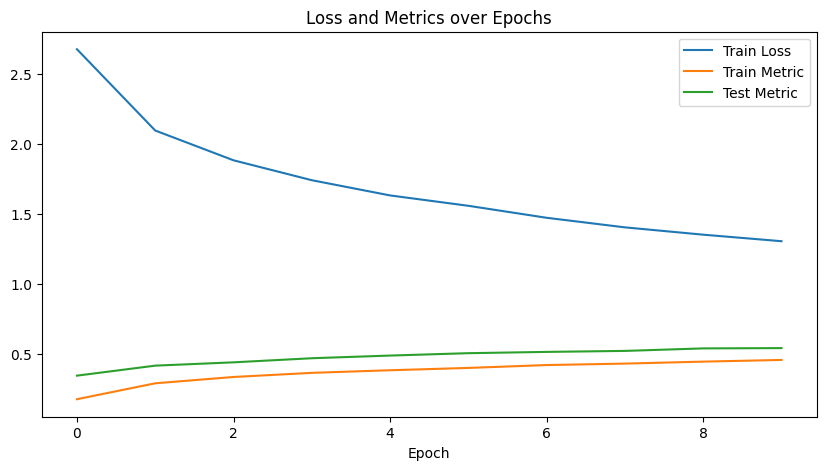

100%|██████████| 10/10 [05:34<00:00, 33.44s/it]


In [45]:
from sklearn.metrics import f1_score

def mean_f1(y_true, y_pred):
    return f1_score(y_true.cpu(), y_pred.cpu(), average='macro')

criterion = nn.CrossEntropyLoss()
model = nn.DataParallel(model)
model.to(device)
metric_values = model_train(
    model = model,
    train_loader = train_loader, test_loader = valid_loader,
    max_epoch = 10, 
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4),
    criterion = criterion, 
    metric = mean_f1)


# Результат обучени и валидации бейзлайна:

 Видим, что бейзлайн имеет не самое лучшее качество.(f1 < 0.6)
 Если сделать модель глубже, то она будет слишком долго обучатья.
 Применим transfer-learning на DenseNet-121
 Это сверточная модель с 121 слоями и 8B параметрами с плотными пропусками (Dense Connections), предобученная на ImageNet.
 
 Заморозим все слои кроме последнего feature-extractor, который реагирует на крупные паттерны

## Попробуем fune-tuning модели DenseNet-121. 
### Это сверточная модель с 121 слоями и 8B параметрами с плотными пропусками (Dense Connections), предобученная на ImageNet.
### Заморозим все слои кроме последнего feature-extractor, который реагирует на крупные паттерны

In [52]:
import torch
import torch.nn as nn
from torchvision.models import densenet121

model = densenet121(weights='DEFAULT') 
#Замораживаем все параметры
for param in model.parameters():
    param.requires_grad = False
    
#Размораживаем последний feature-extractor слой
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
    
#Добавляем один линейный слой
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 42)
)

for param in model.classifier.parameters():
    param.requires_grad = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = nn.DataParallel(model)
model.to(device)

# Вывести инфу о модели
print(f"Model loaded on device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 153MB/s] 


Model loaded on device: cuda
Total parameters: 7090474
Trainable parameters: 2294698


  0%|          | 0/3 [00:00<?, ?it/s]

{'train': [0.7055820835949879], 'test': [0.7413158381288963]}


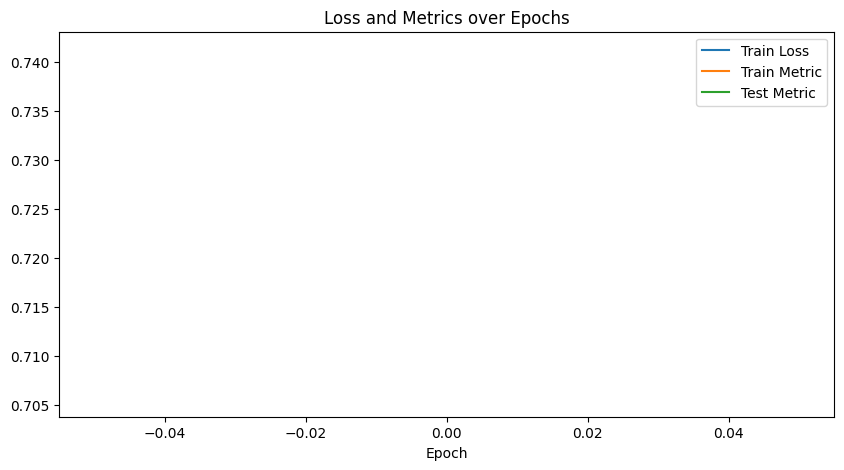

 33%|███▎      | 1/3 [02:05<04:10, 125.19s/it]

{'train': [0.7055820835949879, 0.7924383020167627], 'test': [0.7413158381288963, 0.79112052419636]}


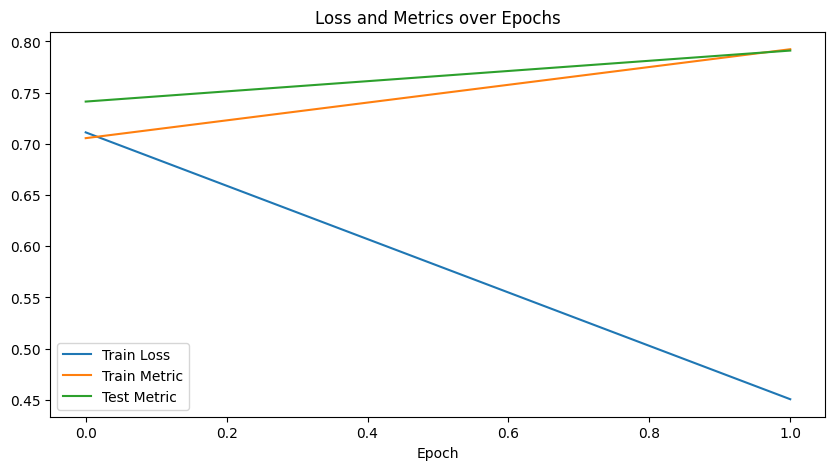

 67%|██████▋   | 2/3 [04:12<02:06, 126.29s/it]

{'train': [0.7055820835949879, 0.7924383020167627, 0.84187279389609], 'test': [0.7413158381288963, 0.79112052419636, 0.801587977058221]}


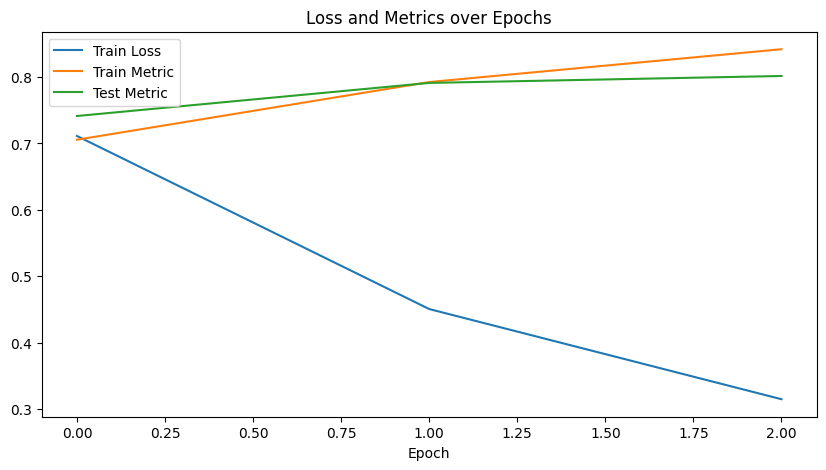

100%|██████████| 3/3 [06:20<00:00, 126.78s/it]


In [57]:
DenseNet_metrics = model_train(
    model = model,
    train_loader = train_loader, test_loader = valid_loader,
    max_epoch = 3, 
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4),
    criterion = criterion, 
    metric = mean_f1)

## За одну эпоху обучения fune-tuned модель принесла скор значительно выше, чем бейзлайн.

### Однако теперь наша модель имеет достаточно много обучаемых параметров, поэтому она быстро переобучится. Добавим аугментации  

также DenseNet обучена на ImageNet, поэтому входные картинки должны быть 224*224

In [70]:
from torch.utils.data import Subset

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_with_augment = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),        # crop+resize вокруг объекта
    transforms.RandomHorizontalFlip(p=0.5),                     # горизонтальное отражение
    transforms.RandomRotation(25),                              # вращение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, 
                           saturation=0.2, hue=0.1),           # цветовые искажения
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,  
                         std=std),
])

# Создаем новые датасеты для обучения и валидации
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_with_augment)

# Validation без аугментаций
val_dataset = datasets.ImageFolder(root=train_dir, transform=transform)

# Делаем split индексов:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
indices = np.random.permutation(len(train_dataset))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_subset = Subset(train_dataset, train_indices) 
val_subset = Subset(val_dataset, val_indices)     

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

 20%|██        | 1/5 [02:42<10:48, 162.23s/it]

{'train': [0.4832290917293162], 'test': [0.6716252292592071]}


 40%|████      | 2/5 [05:25<08:08, 162.79s/it]

{'train': [0.4832290917293162, 0.6957442257506979], 'test': [0.6716252292592071, 0.7384186065907642]}


 60%|██████    | 3/5 [08:07<05:24, 162.47s/it]

{'train': [0.4832290917293162, 0.6957442257506979, 0.756835626305691], 'test': [0.6716252292592071, 0.7384186065907642, 0.7800358849545315]}


 80%|████████  | 4/5 [10:49<02:42, 162.39s/it]

{'train': [0.4832290917293162, 0.6957442257506979, 0.756835626305691, 0.7928037449773669], 'test': [0.6716252292592071, 0.7384186065907642, 0.7800358849545315, 0.8311493691544644]}


100%|██████████| 5/5 [13:32<00:00, 162.43s/it]

{'train': [0.4832290917293162, 0.6957442257506979, 0.756835626305691, 0.7928037449773669, 0.816251179521389], 'test': [0.6716252292592071, 0.7384186065907642, 0.7800358849545315, 0.8311493691544644, 0.8451284439526052]}


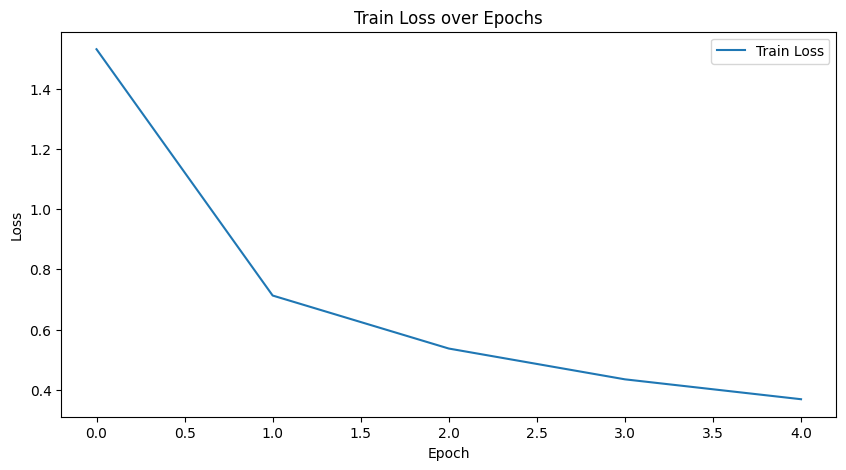

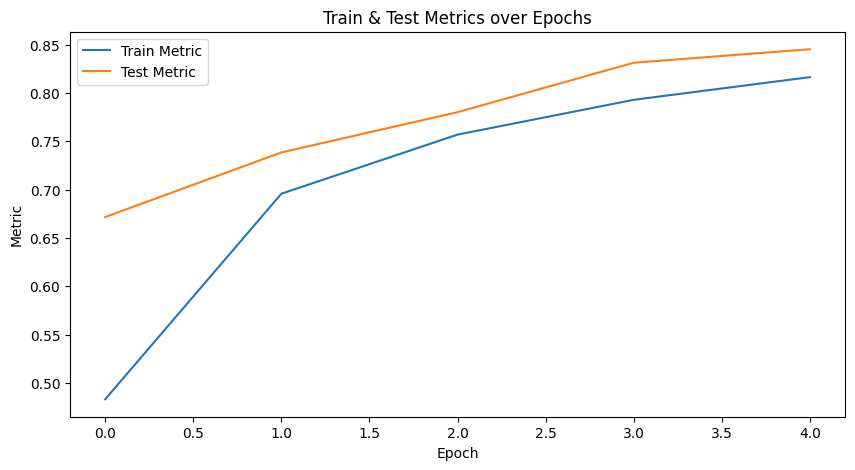

In [71]:
#Занова инициалилизируем модель (все как выше)
model = densenet121(weights='DEFAULT') 

for param in model.parameters():
    param.requires_grad = False
    
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 224),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(224, 42)
)

for param in model.classifier.parameters():
    param.requires_grad = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = nn.DataParallel(model)
model.to(device)
#Заново обучаем модель 
DenseNet_metrics = model_train(
    model = model,
    train_loader = train_loader, test_loader = valid_loader,
    max_epoch = 5, 
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4),
    criterion = criterion, 
    metric = mean_f1)

# Модель обучается лучше и уже меньше подвержена переобучению, теперь

Попробуем добавить регуляризацию и чуть понизить lr

 33%|███▎      | 1/3 [02:41<05:22, 161.18s/it]

{'train': [0.87783805974814], 'test': [0.8631672688226326]}


 67%|██████▋   | 2/3 [05:24<02:42, 162.20s/it]

{'train': [0.87783805974814, 0.891172377886823], 'test': [0.8631672688226326, 0.8804542713097367]}


100%|██████████| 3/3 [08:07<00:00, 162.58s/it]

{'train': [0.87783805974814, 0.891172377886823, 0.9020416950964336], 'test': [0.8631672688226326, 0.8804542713097367, 0.884506756483341]}


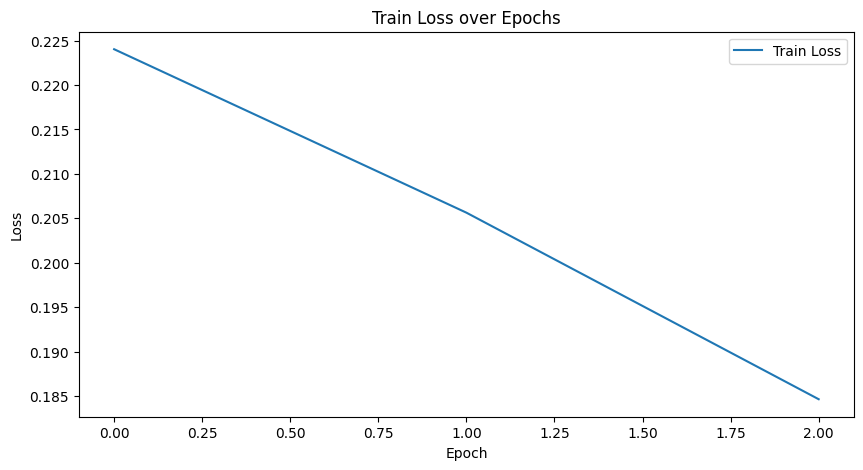

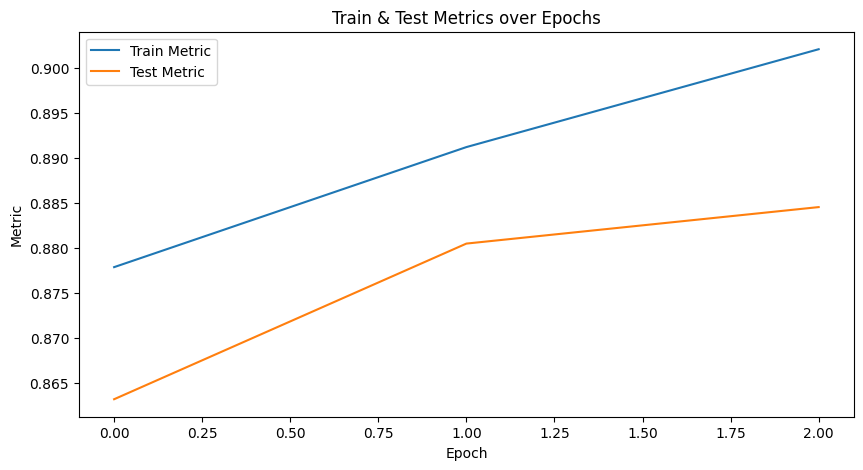

In [73]:
DenseNet_metrics = model_train(
    model = model,
    train_loader = train_loader, test_loader = valid_loader,
    max_epoch = 3, 
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay = 1e-4),
    criterion = criterion, 
    metric = mean_f1)

## Скор растет медленно еще до отметок 0.9 
### Сохраним модель и попробуем что нибудь новое

In [74]:
torch.save(model.module.state_dict(), "tuned_densenet.pth")
#код для загрузки 
"""model.load_state_dict(torch.load("tuned_densenet.pth")
"""

'model.load_state_dict(torch.load("model_weights.pth"))\n'

# Разморозим на один feat-extracted слой больше 
P.S. это было хорошей идеей

 20%|██        | 1/5 [02:55<11:43, 175.99s/it]

{'train': [0.601882428386226], 'test': [0.7645160131019614]}


 40%|████      | 2/5 [05:51<08:46, 175.66s/it]

{'train': [0.601882428386226, 0.7913606235703363], 'test': [0.7645160131019614, 0.8304759672525873]}


 60%|██████    | 3/5 [08:47<05:51, 175.66s/it]

{'train': [0.601882428386226, 0.7913606235703363, 0.8514446561939429], 'test': [0.7645160131019614, 0.8304759672525873, 0.8717980530979111]}


 80%|████████  | 4/5 [11:41<02:55, 175.31s/it]

{'train': [0.601882428386226, 0.7913606235703363, 0.8514446561939429, 0.889533619916833], 'test': [0.7645160131019614, 0.8304759672525873, 0.8717980530979111, 0.889692425711866]}


100%|██████████| 5/5 [14:37<00:00, 175.41s/it]

{'train': [0.601882428386226, 0.7913606235703363, 0.8514446561939429, 0.889533619916833, 0.899697970687732], 'test': [0.7645160131019614, 0.8304759672525873, 0.8717980530979111, 0.889692425711866, 0.9051520342436595]}


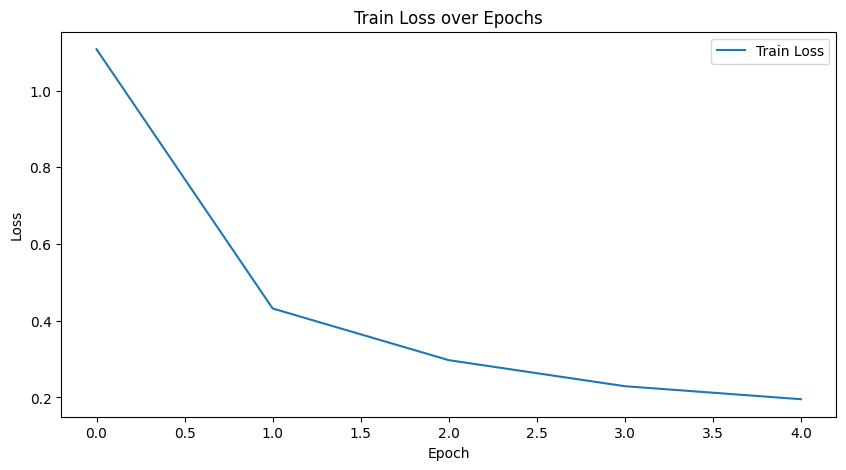

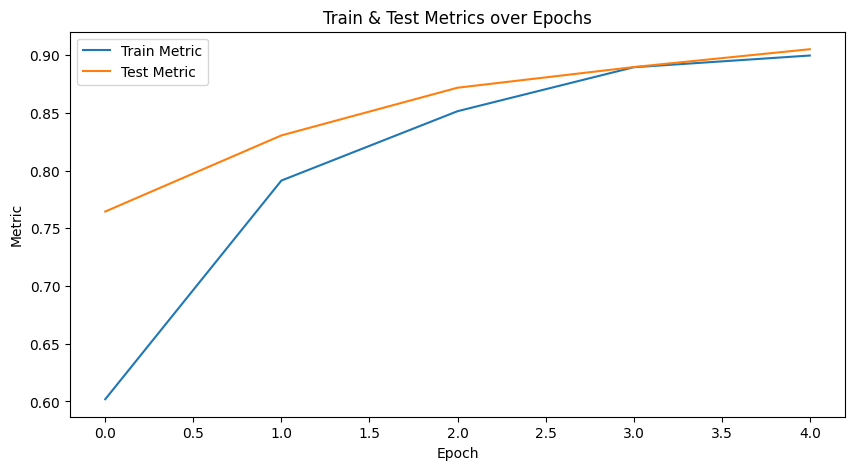

In [75]:
model = densenet121(weights='DEFAULT') 
for param in model.parameters():
    param.requires_grad = False
    
#Размораживаем последние 2 feature-extractor слоя
for param in model.features.denseblock3.parameters():
    param.requires_grad = True
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
    
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 42)
)

for param in model.classifier.parameters():
    param.requires_grad = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = nn.DataParallel(model)
model.to(device)
#Заново обучаем модель 
DenseNet_metrics = model_train(
    model = model,
    train_loader = train_loader, test_loader = valid_loader,
    max_epoch = 5, 
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4,weight_decay = 3e-4),
    criterion = criterion, 
    metric = mean_f1)

# Видим отличный скор
### Чтобы модель не переобучалась(параметров очень много, увеличим степень регуляризации и уменьшим learning_rate

In [79]:
DenseNet_metrics = model_train(
    model = model,
    train_loader = train_loader, test_loader = valid_loader,
    max_epoch = 5, 
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4,weight_decay = 2e-3),
    criterion = criterion, 
    metric = mean_f1)

 20%|██        | 1/5 [02:56<11:44, 176.16s/it]

{'train': [0.9605073791168279], 'test': [0.9363350432383585]}


 40%|████      | 2/5 [05:51<08:47, 175.70s/it]

{'train': [0.9605073791168279, 0.96229915831375], 'test': [0.9363350432383585, 0.9421337331764053]}


 60%|██████    | 3/5 [08:47<05:51, 175.71s/it]

{'train': [0.9605073791168279, 0.96229915831375, 0.9655994218959337], 'test': [0.9363350432383585, 0.9421337331764053, 0.9431402632910811]}


 60%|██████    | 3/5 [08:57<05:58, 179.11s/it]


KeyboardInterrupt: 

# Еще сильнее увеличив регуляризацию и уменьшив learning rate, добаваемся хорошего скора и формируем ответ:

 50%|█████     | 1/2 [02:56<02:56, 176.40s/it]

{'train': [0.9713867425161898], 'test': [0.9517024366963978]}


100%|██████████| 2/2 [05:53<00:00, 176.96s/it]

{'train': [0.9713867425161898, 0.9741080235873714], 'test': [0.9517024366963978, 0.9466645737831885]}


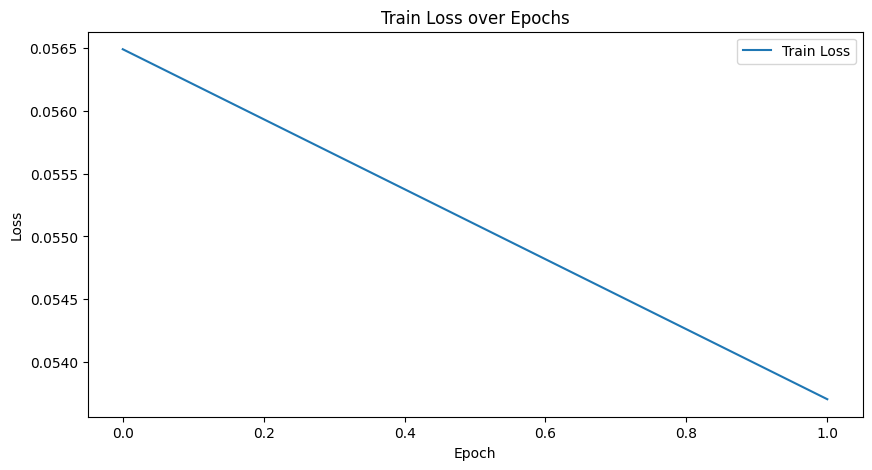

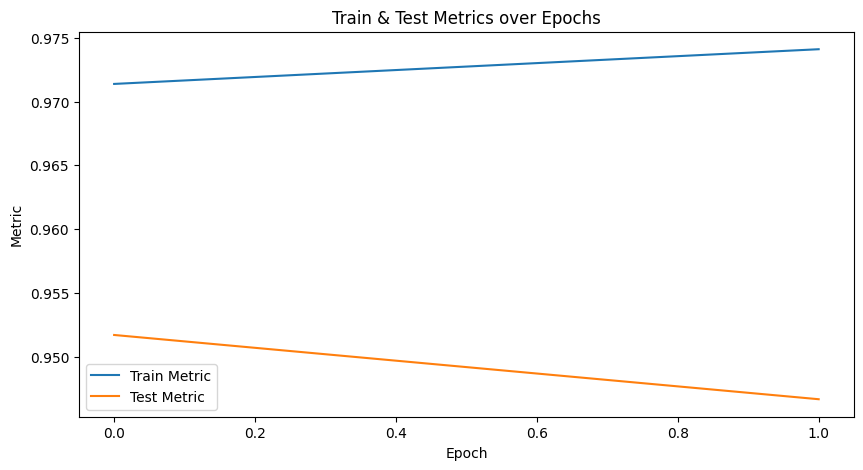

In [80]:
DenseNet_metrics = model_train(
    model = model,
    train_loader = train_loader, test_loader = valid_loader,
    max_epoch = 2, 
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-5,weight_decay = 7e-3),
    criterion = criterion, 
    metric = mean_f1)

In [82]:
#Сохраняем сабмит
test_dir = '/kaggle/input/journey-to-springfield1/testset/testset'
test_files = sorted(os.listdir(test_dir))

model.eval()
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

results = []
device = 'cuda' if torch.cuda.is_available() else 'cpu'

with torch.no_grad():
    for fname in test_files:
        img_path = os.path.join(test_dir, fname)
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)
        output = model(img_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        class_label = idx_to_class[pred_idx]
        results.append({'Id': fname, 'Expected': class_label})

sub_df = pd.DataFrame(results)
sub_df = sub_df.sort_values('Id').reset_index(drop=True)
sub_df.to_csv('submission.csv', index=False)


# Скор на тестовой выборке 0.994